# Analisis de Sentimientos en reseñas de canciones digitales



## Librerias

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import spacy
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from wordcloud import WordCloud

import warnings

warnings.filterwarnings("ignore")
nlp = spacy.load("en_core_web_sm")
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/jhonattan.reales/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## Datos

In [2]:
# Descargamos el conjunto de reseñas desde nuestro repositorio
# !wget -O Digital_Music_5.json https://raw.githubusercontent.com/Can0land/NLP-Laboratory/refs/heads/main/Digital_Music_5.json

Cargamos el dataset de reseñas, teniendo en cuenta que es un archivo json

In [3]:
df = pd.read_json("./Digital_music_5.json", lines=True)
df.head(3)

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,image
0,5,3.0,True,"06 3, 2013",A2TYZ821XXK2YZ,3426958910,{'Format:': ' Audio CD'},Garrett,"This is awesome to listen to, A must-have for ...",Slayer Rules!,1370217600,NaN
1,5,NaN,True,"10 11, 2014",A3OFSREZADFUDY,3426958910,{'Format:': ' Audio CD'},Ad,bien,Five Stars,1412985600,NaN
2,5,NaN,True,"02 11, 2014",A2VAMODP8M77NG,3426958910,{'Format:': ' Audio CD'},JTGabq,It was great to hear the old stuff again and I...,SLAYER!!!!!!!!!!!!!!!!!!!!!,1392076800,NaN


Eliminamos columnas que no son necesarias para nuestro analisis de sentimientos

In [4]:
df_music = df.drop(
    [
        "reviewTime",
        "unixReviewTime",
        "reviewerID",
        "image",
        "asin",
        "reviewerName",
        "verified",
    ],
    axis=1,
)
df_music.sample(10)

,overall,vote,style,reviewText,summary
77323,5,NaN,{'Format:': ' MP3 Music'},Not a bible thumper but this is a winner.,Great female vocal
72015,5,NaN,{'Format:': ' MP3 Music'},Amazing song! I am always looking for a good s...,General review
30201,4,NaN,{'Format:': ' MP3 Music'},I think it is a good song but you will have to...,A Good Song
56714,5,NaN,{'Format:': ' MP3 Music'},Great song!,Five Stars
20579,4,NaN,NaN,has a lot of hits. good collection.,good collection.
49912,5,NaN,{'Format:': ' MP3 Music'},Good old tune,Five Stars
91924,5,NaN,{'Format:': ' MP3 Music'},Great song.,Five Stars
79207,5,NaN,{'Format:': ' MP3 Music'},Such a perfect song. Forgiveness is one of the...,Five Stars
49793,5,NaN,{'Format:': ' MP3 Music'},Whenever I miss running the boardwalk in Wildw...,Wildwood boardwalk in the winter.
37752,5,NaN,{'Format:': ' MP3 Music'},One of my favorite songs from her. She has a ...,Thank You


Nuestra tabla de reseñas ahora cuenta con las siguientes 5 columnas:

- overall: calificación general del producto (1-5)
- vote: calificación del comentario por parte de otros usuarios
- style: estilo del producto
- reviewText: texto de la reseña
- summary: resumen de la reseña

### Limpieza de datos
Verificamos la calidad de las columnas, y limpiamos los datos

In [5]:
df_music.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169781 entries, 0 to 169780
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   overall     169781 non-null  int64  
 1   vote        7611 non-null    float64
 2   style       157989 non-null  object 
 3   reviewText  169623 non-null  object 
 4   summary     169745 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 6.5+ MB


A continuación, aplicaremos algunos pasos de limpieza

In [6]:
# Eliminamos todas las filas con valores nulos en las columnas style y revieText
df_music = df_music.dropna(subset=["style", "reviewText"])

# Modificamos la columna style para que solo tengas valores tipo texto, sin diccionario
df_music["style"] = df_music["style"].apply(
    lambda x: x.get("Format:") if isinstance(x, dict) else None
)
# A la columna vote, los valores nulos los cambiamos por 0
df_music["vote"] = df_music["vote"].fillna(0)

# las columnas tipo texto, le cambiamos las mayusculas por minusculas y le quitamos espamos en blanco al princpio o al final
df_music["reviewText"] = df_music["reviewText"].str.lower().str.strip()
df_music["summary"] = df_music["summary"].str.lower().str.strip()

In [7]:
df_music.sample(2)

,overall,vote,style,reviewText,summary
126832,4,0.0,MP3 Music,clever song,four stars
166505,5,0.0,MP3 Music,great song,those english boys


## EDA
Realizar un EDA para entender el comportamiento y posibles valores de cada variable.


### Variables no tipo texto

In [8]:
df_music.describe()

,overall,vote
count,157835.000000,157835.000000
mean,4.707840,0.374473
std,0.701844,4.417204
min,1.000000,0.000000
25%,5.000000,0.000000
50%,5.000000,0.000000
75%,5.000000,0.000000
max,5.000000,461.000000


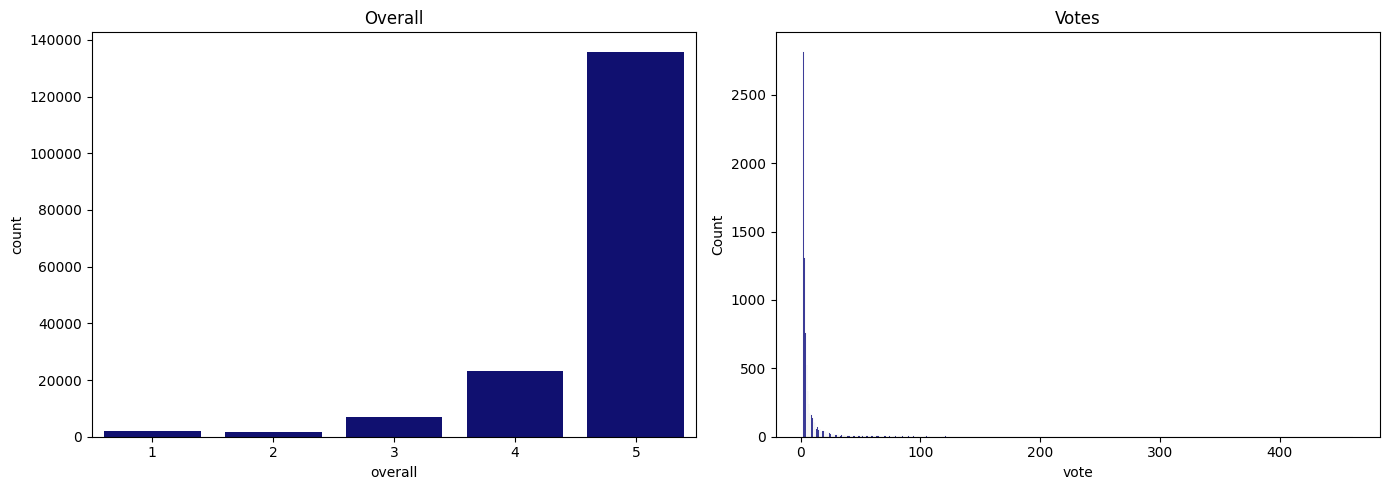

In [9]:
# Graficamos el conteo de las puntuaciones y los votos de cada reseña
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="overall", color="navy", ax=axes[0])
axes[0].set_title("Overall")

sns.histplot(data=df, x="vote", color="navy", ax=axes[1])
axes[1].set_title("Votes")

plt.tight_layout()
plt.show()

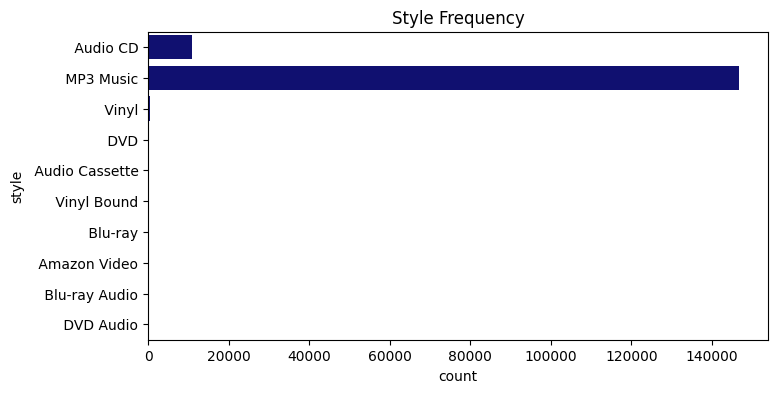

In [10]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df_music, y="style", color="navy")
plt.title("Style Frequency")
plt.show()

notas:

In [45]:
# Escogeremos al azar el 5% de las reseñas con overall iguales a 5
# el 30% de las reseñas con overall iguales a 3 o 4
# y el 100% de las reseñas 1 o 2 para tener un dataset balanceado
positive_reviews = df_music[df_music["overall"] == 5].sample(frac=0.05, random_state=15)
neutral_reviews = df_music[df_music["overall"].isin([3, 4])].sample(
    frac=0.3, random_state=15
)
negative_reviews = df_music[df_music["overall"] < 3]

# Unimos en un solo dataframe las reseñas positivas, neutrales y negativas
balanced_df = pd.concat([positive_reviews, neutral_reviews, negative_reviews])

# seleccionamos 5000 reseñas al azar del dataframe balanceado para trabajar con un dataset más pequeño
balanced_df = balanced_df.sample(n=5000, random_state=15)

In [46]:
balanced_df["overall"].value_counts()

overall
4    1791
5    1753
1     553
3     518
2     385
Name: count, dtype: int64

In [47]:
balanced_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 169110 to 35871
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   overall     5000 non-null   int64  
 1   vote        5000 non-null   float64
 2   style       5000 non-null   object 
 3   reviewText  5000 non-null   object 
 4   summary     5000 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 234.4+ KB


### Variables tipo texto

In [ ]:
"""
De cada variable con textos (principalmente reviewText), obtendremos:
- El numero de tokens (no espacios ni puntuaciones) y luego graficaremos dicha distribución de manera univariada y bivariada junto a la puntuación de la reseña
- El numero de sentencias y graficamos.
- Graficaremos una nube de  palabras para determinar las palabras mas frecuentes, tanto a nivel general, como cruzado con la puntuación.
"""

'\nDe cada variable con textos (principalmente reviewText), obtendremos:\n- El numero de tokens (no espacios ni puntuaciones) y luego graficaremos dicha distribución de manera univariada y bivariada junto a la puntuación de la reseña\n- El numero de sentencias y graficamos.\n- El numero promedio de palabras por oración, tanto global como cruzado con la puntuación.\n- Graficaremos una nube de  palabras para determinar las palabras mas frecuentes, tanto a nivel general, como cruzado con la puntuación.\n'

### Numero de Tokens

In [ ]:
# Función para contar el número de tokens alfanuméricos en una oración sin contar espacios ni puntuaciones
def count_alphanumeric_tokens(sentence):
    doc = nlp(str(sentence))
    t_vector = [t for t in doc if not t.is_punct and not t.is_space]
    return len(t_vector)

In [ ]:
temp_df = balanced_df.copy()
temp_df["review_tokens "] = temp_df["reviewText"].apply(count_alphanumeric_tokens)
temp_df["summary_tokens"] = temp_df["summary"].apply(count_alphanumeric_tokens)
temp_df

,overall,vote,style,reviewText,summary,review_tokens,summary_tokens
169110,5,0.0,Audio CD,dope,five stars,1,2
141174,5,0.0,MP3 Music,a sentimental and sappy song. but sweet if th...,do you even need a review?,86,6
155355,4,0.0,MP3 Music,i would not mind having my husband's hands mov...,hands country style,37,3


### Numero de Tokens

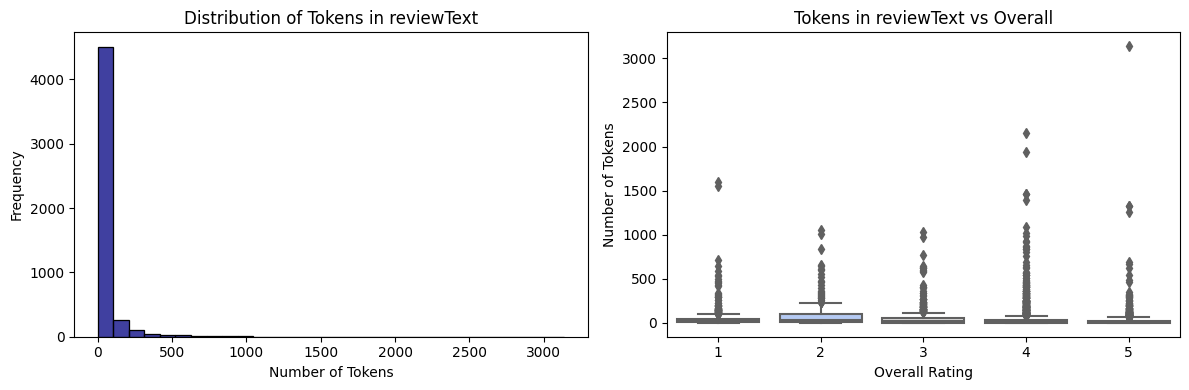

In [52]:
# Graficamos la distribución de tokens en reviewText, univariado y vs overall
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(temp_df["review_tokens "], color="navy", bins=30)
plt.title("Distribution of Tokens in reviewText")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x="overall", y="review_tokens ", data=temp_df, palette="coolwarm")
plt.title("Tokens in reviewText vs Overall")
plt.xlabel("Overall Rating")
plt.ylabel("Number of Tokens")

plt.tight_layout()
plt.show()

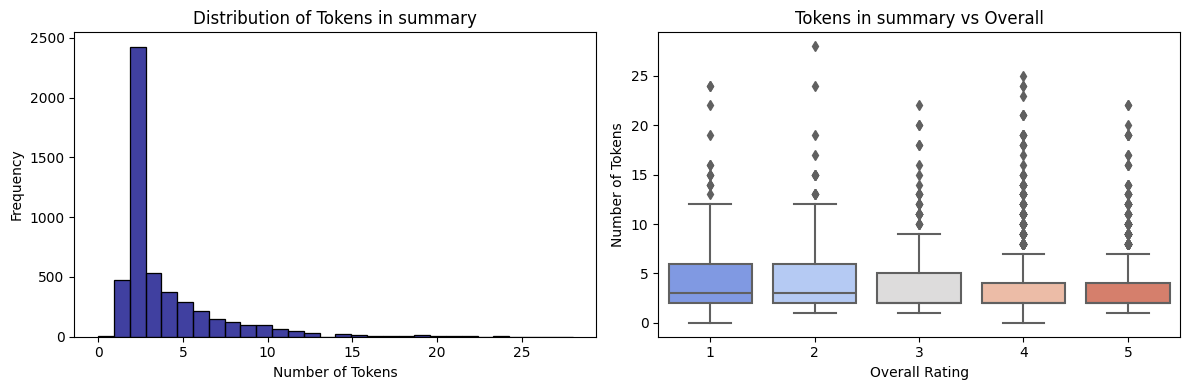

In [54]:
# Graficamos la distribución de tokens en summary, univariado y vs overall
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(temp_df["summary_tokens"], color="navy", bins=30)
plt.title("Distribution of Tokens in summary")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x="overall", y="summary_tokens", data=temp_df, palette="coolwarm")
plt.title("Tokens in summary vs Overall")
plt.xlabel("Overall Rating")
plt.ylabel("Number of Tokens")

plt.tight_layout()
plt.show()

### Numero de sentencias

In [56]:
# Función para contar el número de sentencias en cada reseña
def count_sentences(text):
    doc = nlp(str(text))
    return len(list(doc.sents))

In [57]:
temp_df = balanced_df.copy()
temp_df["review_sentences"] = temp_df["reviewText"].apply(count_sentences)
temp_df["summary_sentences"] = temp_df["summary"].apply(count_sentences)
temp_df

,overall,vote,style,reviewText,summary,review_sentences,summary_sentences
169110,5,0.0,Audio CD,dope,five stars,1,1
141174,5,0.0,MP3 Music,a sentimental and sappy song. but sweet if th...,do you even need a review?,5,1
155355,4,0.0,MP3 Music,i would not mind having my husband's hands mov...,hands country style,3,1
82874,5,0.0,Audio CD,these young men are amazing for the depth that...,totally enchanging,3,1
112255,1,0.0,MP3 Music,i never heard or saw this group outside of ama...,i'm looking forward to more music from them,1,1
...,...,...,...,...,...,...,...
169440,4,0.0,MP3 Music,great!!!,four stars,1,1
166820,4,0.0,MP3 Music,love this song.,four stars,1,1
125081,4,0.0,MP3 Music,got to have ll on my 90s hip hop list and i di...,great track,2,1
65540,3,0.0,MP3 Music,only plays in amazon app or on mp3 player; not...,good quality download,1,1


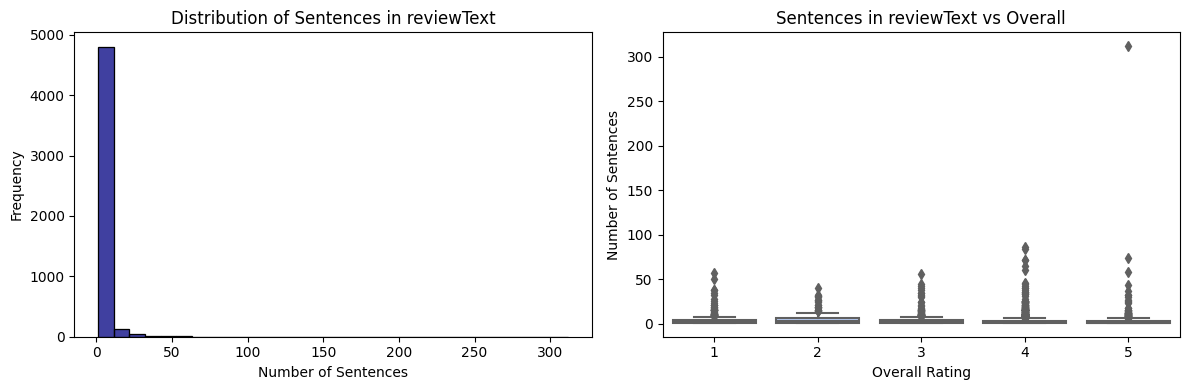

In [58]:
# Graficamos la distribución del numero de sentencias en reviewText, univariado y vs overall
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(temp_df["review_sentences"], color="navy", bins=30)
plt.title("Distribution of Sentences in reviewText")
plt.xlabel("Number of Sentences")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x="overall", y="review_sentences", data=temp_df, palette="coolwarm")
plt.title("Sentences in reviewText vs Overall")
plt.xlabel("Overall Rating")
plt.ylabel("Number of Sentences")

plt.tight_layout()
plt.show()

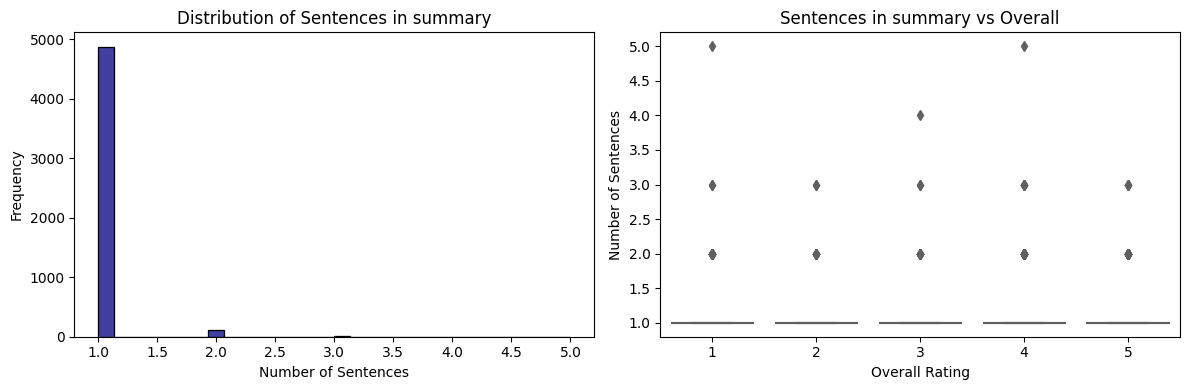

In [59]:
# Graficamos a distribución del numero de sentencias en summary, univariado y vs overall
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(temp_df["summary_sentences"], color="navy", bins=30)
plt.title("Distribution of Sentences in summary")
plt.xlabel("Number of Sentences")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x="overall", y="summary_sentences", data=temp_df, palette="coolwarm")
plt.title("Sentences in summary vs Overall")
plt.xlabel("Overall Rating")
plt.ylabel("Number of Sentences")

plt.tight_layout()
plt.show()

### Wordcloud

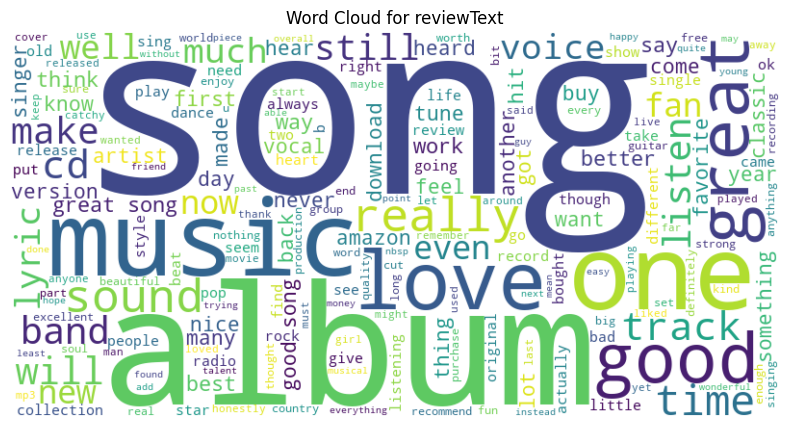

In [ ]:
# Nube de palabras general para reviewText
all_text = " ".join(balanced_df["reviewText"].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(
    all_text
)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for reviewText")
plt.show()

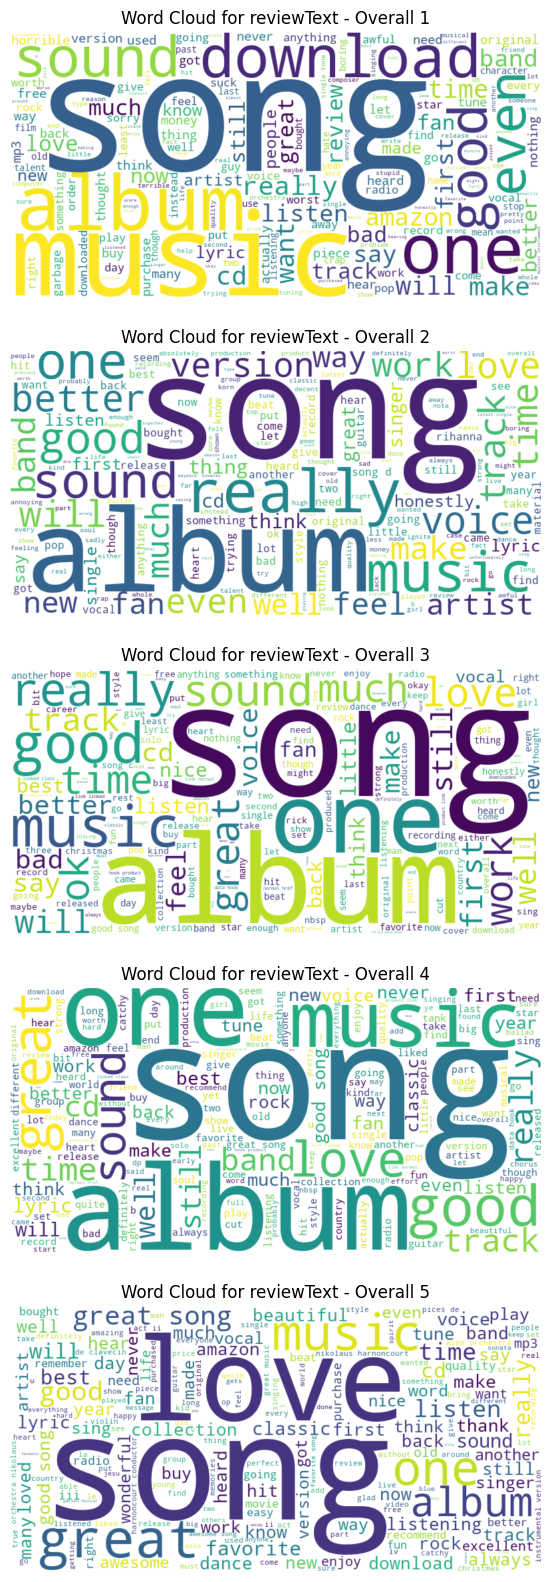

In [66]:
# Nube de palabras de reviewText por cada nivel de overall
plt.figure(figsize=(12, 20))

overall_levels = sorted(balanced_df["overall"].unique())
for i, level in enumerate(overall_levels):

    plt.subplot(len(overall_levels), 1, i + 1)
    level_text = " ".join(
        balanced_df[balanced_df["overall"] == level]["reviewText"].astype(str)
    )

    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(
        level_text
    )
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for reviewText - Overall {level}")

# plt.tight_layout()
plt.show()

## Pre-procesamiento

## Analisis de sentimiento

### Vard modelo

### modelo #2

## Analisis de resultados

## Conclusion